In [1]:
# !pip uninstall -y  datasets

In [2]:
!pip install datasets==2.18.0


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import torch
import pandas as pd
import soundfile as sf
from jiwer import wer
import datasets
from transformers import WhisperProcessor, WhisperForConditionalGeneration

In [38]:
from datasets import load_dataset
fleurs = load_dataset("google/fleurs", "hi_in", split="train")

df = fleurs.select(range(5))
print("✅ Dataset loaded successfully")

C:\Users\Dexter\AppData\Local\Programs\Python\Python313\Lib\site-packages\datasets\load.py:1461: FutureWarning: The repository for google/fleurs contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/google/fleurs
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this dataset from the next major release of `datasets`.
  warnings.warn(


✅ Dataset loaded successfully


In [39]:
df[1]

{'id': 873,
 'num_samples': 177600,
 'path': 'C:\\Users\\Dexter\\.cache\\huggingface\\datasets\\downloads\\extracted\\40bb53bee8b7ed66b3175b83d108ccba3b938c6689c368c0e37b37b9bb34d7c2\\1000501302680129094.wav',
 'audio': {'path': 'train/1000501302680129094.wav',
  'array': array([0.        , 0.        , 0.        , ..., 0.00210315, 0.00220305,
         0.00166202], shape=(177600,)),
  'sampling_rate': 16000},
 'transcription': 'जब आप छुट्टी पर होते हैं तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें',
 'raw_transcription': 'जब आप छुट्टी पर होते हैं, तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें।',
 'gender': 0,
 'lang_id': 32,
 'language': 'Hindi',
 'lang_group_id': 4}

In [40]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "openai/whisper-small"

# Base model
base_model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

# Fine-tuned model (LOCAL)
fine_model = WhisperForConditionalGeneration.from_pretrained("./model_final").to(device)

# Processor
processor = WhisperProcessor.from_pretrained("./model_final")

print("✅ Models loaded")


Using device: cpu


Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/479 [00:00<?, ?it/s]

✅ Models loaded


In [41]:
import os
references=[]
base_preds=[]
fine_preds=[]

base_dir = r"C:\Users\Dexter\.cache\huggingface\datasets\downloads\extracted\40bb53bee8b7ed66b3175b83d108ccba3b938c6689c368c0e37b37b9bb34d7c2\train"

for row in df:
    filename = os.path.basename(row["path"])
    audio_path = os.path.join(base_dir, filename)

    ref_text =row["transcription"]

    print(f"\nProcessing : {audio_path}")

    try:
        if not os.path.exists(audio_path):
            print(f"❌ File missing: {audio_path}")
            continue

        base_text = transcribe(base_model, audio_path)
        fine_text = transcribe(fine_model, audio_path)

        base_preds.append(base_text)
        fine_preds.append(fine_text)
        references.append(ref_text)

        print("Reference :", ref_text)
        print("Base      :", base_text)
        print("Fine      :", fine_text)

    except Exception as e:
        print(f"❌ Error: {e}")


Processing : C:\Users\Dexter\.cache\huggingface\datasets\downloads\extracted\40bb53bee8b7ed66b3175b83d108ccba3b938c6689c368c0e37b37b9bb34d7c2\train\10002503286825416621.wav
Reference : राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी
Base      :  راج نیتیگیوں نے کہا کہ انہوں نے نرنایق مت کو انوائشک روبصر ندارت کرنے کے لیہ افغان سے ودھان میں کافی اспشت لہ بائی تھی
Fine      :  राजनी तीग यो ने कहां कि उना ने नायक मत्को अनावाश्यक रुपसर ने दारिट करने के लिया अप्गान सा विद्डान में का फी आस पस्टला पाइती थी

Processing : C:\Users\Dexter\.cache\huggingface\datasets\downloads\extracted\40bb53bee8b7ed66b3175b83d108ccba3b938c6689c368c0e37b37b9bb34d7c2\train\1000501302680129094.wav
Reference : जब आप छुट्टी पर होते हैं तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें
Base      :  जब आप चुट्टी पर हुते हैं तो आप किपास खुट किले समें हुता है और कुच विषेश करने किले अट्रिक समें निकालें
Fine      

In [ ]:
print("\nCollected samples:", len(references))

if len(references) == 0:
    print("❌ No data processed. Fix audio paths.")
else:
   
    def normalize(x):
        return x.lower().strip()

    references_n = [normalize(x) for x in references]
    base_preds_n = [normalize(x) for x in base_preds]
    fine_preds_n = [normalize(x) for x in fine_preds]

    base_wer = wer(references_n, base_preds_n)
    fine_wer = wer(references_n, fine_preds_n)

    print("\n======================")
    print(f"Base Model WER : {base_wer}")
    print(f"Fine Model WER : {fine_wer}")
    print("======================")

    if fine_wer < base_wer:
        print("✅ Fine-tuned model performs better")
    else:
        print("⚠️ Fine-tuned model did not improve")


Collected samples: 5

Base Model WER : 0.6456692913385826
Fine Model WER : 0.5826771653543307
✅ Fine-tuned model performs better


In [43]:
for i in range(len(references)):
    print("\n--- Sample ---")
    print("Reference :", references[i])
    print("Base      :", base_preds[i])
    print("Fine      :", fine_preds[i])


--- Sample ---
Reference : राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी
Base      :  راج نیتیگیوں نے کہا کہ انہوں نے نرنایق مت کو انوائشک روبصر ندارت کرنے کے لیہ افغان سے ودھان میں کافی اспشت لہ بائی تھی
Fine      :  राजनी तीग यो ने कहां कि उना ने नायक मत्को अनावाश्यक रुपसर ने दारिट करने के लिया अप्गान सा विद्डान में का फी आस पस्टला पाइती थी

--- Sample ---
Reference : जब आप छुट्टी पर होते हैं तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें
Base      :  जब आप चुट्टी पर हुते हैं तो आप किपास खुट किले समें हुता है और कुच विषेश करने किले अट्रिक समें निकालें
Fine      :  जब आप जुटी पर होते हैं तो आपकी पास खुद के लें समें होता हैं और कुछ विशेश करने के लिए आप द्रिक्त समें निकालें

--- Sample ---
Reference : वाइल्डलाइफ़ फ़ोटोग्राफ़ी को अक्सर हल्के में ही लिया जाता है लेकिन सामान्यतः फ़टोग्राफ़ी की तरह ही एक चित्र हज़ारों शब्द से अधिक कीमत रखता है
Base      :  वाईलाईप पोट़ग्राफी को

In [44]:
print("Empty base preds:", sum([1 for x in base_preds if x.strip() == ""]))
print("Empty fine preds:", sum([1 for x in fine_preds if x.strip() == ""]))

Empty base preds: 0
Empty fine preds: 0


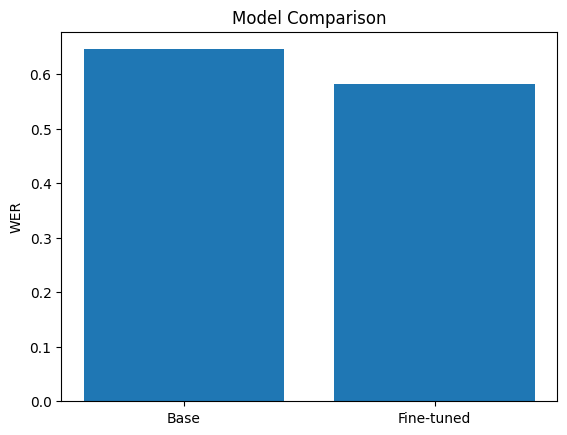

In [46]:
import matplotlib.pyplot as plt

models = ["Base", "Fine-tuned"]
wer_scores = [base_wer, fine_wer]

plt.bar(models, wer_scores)
plt.ylabel("WER")
plt.title("Model Comparison")
plt.show()

In [48]:
errors = []

for ref, pred in zip(references, fine_preds):
    if ref != pred:
        errors.append((ref, pred))

# systematic sampling
sampled_errors = errors[::2][:25]
print(sampled_errors)

[('राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी', ' राजनी तीग यो ने कहां कि उना ने नायक मत्को अनावाश्यक रुपसर ने दारिट करने के लिया अप्गान सा विद्डान में का फी आस पस्टला पाइती थी'), ('वाइल्डलाइफ़ फ़ोटोग्राफ़ी को अक्सर हल्के में ही लिया जाता है लेकिन सामान्यतः फ़टोग्राफ़ी की तरह ही एक चित्र हज़ारों शब्द से अधिक कीमत रखता है', ' वाइल्टाइप फोट्राफी को अच्छर हलके में ही लिया जाता है लेकिन सामानेता फोट्राफी की तरहें एक चित्र हाँरो सबत्से अदिक कीमत रकता है'), ('जुडियन हिल्स के प्राचीन शहर में हज़ारों सालों से एक लुभावना इतिहास है', ' जुड्यान हेल्स के प्राछीं शहर में हाजारो सालों से एक लुबहावना इतिहाआश है')]


In [49]:
def normalize(text):
    return text.lower().strip()

references_n = [normalize(x) for x in references]
preds_n = [normalize(x) for x in fine_preds]

In [50]:
print(references_n)
print(preds_n)


['राजनीतिज्ञों ने कहा कि उन्होंने निर्णायक मत को अनावश्यक रूप से निर्धारित करने के लिए अफ़गान संविधान में काफी अस्पष्टता पाई थी', 'जब आप छुट्टी पर होते हैं तो आपके पास खुद के लिए समय होता है और कुछ विशेष करने के लिए अतिरिक्त समय निकालें', 'वाइल्डलाइफ़ फ़ोटोग्राफ़ी को अक्सर हल्के में ही लिया जाता है लेकिन सामान्यतः फ़टोग्राफ़ी की तरह ही एक चित्र हज़ारों शब्द से अधिक कीमत रखता है', 'ट्रैवल एजेंसियां 19 वीं शताब्दी के बाद से आई हैं एक ट्रैवल एजेंट आमतौर पर एक ऐसी यात्रा के लिए एक अच्छा विकल्प होता है जो प्रकृति संस्कृति भाषा या कम आय वाले देशों के यात्रा के पिछले अनुभव से अलग होता है', 'जुडियन हिल्स के प्राचीन शहर में हज़ारों सालों से एक लुभावना इतिहास है']
['राजनी तीग यो ने कहां कि उना ने नायक मत्को अनावाश्यक रुपसर ने दारिट करने के लिया अप्गान सा विद्डान में का फी आस पस्टला पाइती थी', 'जब आप जुटी पर होते हैं तो आपकी पास खुद के लें समें होता हैं और कुछ विशेश करने के लिए आप द्रिक्त समें निकालें', 'वाइल्टाइप फोट्राफी को अच्छर हलके में ही लिया जाता है लेकिन सामानेता फोट्राफी की तरहें एक चित्